In [12]:
import pandas as pd
import numpy as np
import time


NUM_ROWS = 10000 

print(f"Generating {NUM_ROWS} rows of synthetic sensor data...")


data = {
    'Timestamp': [],
    'Pixel_X': [],
    'Pixel_Y': [],
    'Depth_mm': [],
    'Temperature_C': [],
    'ToF_Amplitude': [],
    'Target_Label': []
}


categories = ['Victim', 'Surroundings', 'Heated Object']
current_time = time.time()

for _ in range(NUM_ROWS):
   
    label = np.random.choice(categories, p=[0.4, 0.5, 0.1]) 
    
   
    data['Pixel_X'].append(np.random.randint(0, 640))
    data['Pixel_Y'].append(np.random.randint(0, 480))
    data['Timestamp'].append(current_time + np.random.uniform(0, 10))
    data['Target_Label'].append(label)

    
    if label == 'Victim':
        data['Depth_mm'].append(np.random.normal(2000, 300))      
        data['Temperature_C'].append(np.random.normal(37, 1.0)) 
        data['ToF_Amplitude'].append(np.random.randint(70, 100))  
        
    elif label == 'Surroundings':
        data['Depth_mm'].append(np.random.normal(3500, 800))      
        data['Temperature_C'].append(np.random.normal(22.0, 2.0)) 
        data['ToF_Amplitude'].append(np.random.randint(20, 60))   
        
    elif label == 'Heated Object':
        data['Depth_mm'].append(np.random.normal(2000, 500))      
        data['Temperature_C'].append(np.random.normal(55.0, 5.0))
        data['ToF_Amplitude'].append(np.random.randint(60, 95))   


df = pd.DataFrame(data)


df['Depth_mm'] = df['Depth_mm'].round(1)
df['Temperature_C'] = df['Temperature_C'].round(1)
df['Timestamp'] = df['Timestamp'].round(3)

# Save to your computer
csv_filename = 'fused_sensor_training_data.csv'
df.to_csv(csv_filename, index=False)

print(f"Success! Saved perfectly formatted data to {csv_filename}")

Generating 10000 rows of synthetic sensor data...
Success! Saved perfectly formatted data to fused_sensor_training_data.csv


# Read the existing .csv file

In [23]:
import pandas as pd
df = pd.read_csv("/content/fused_sensor_training_data_high_altitude.csv")

df_clean = df[df['ToF_Amplitude'] > 30].copy()

# Handle any missing values (NaNs)
df_clean = df_clean.dropna()

print(f"Original rows: {len(df)}, Cleaned row: {len(df_clean)}")

Original rows: 50000, Cleaned row: 49967


# Implementing random forest classifier for train the model

In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings
import pickle
warnings.filterwarnings("ignore")

# Load your dataset
data = pd.read_csv("/content/fused_sensor_training_data_high_altitude.csv")


# Features: The data the model will learn from (e.g., Depth and position)
X = df_clean[['Pixel_X', 'Pixel_Y', 'Depth_mm', 'ToF_Amplitude']]

# Labels: The target category you want the model to predict
y = df_clean['Target_Label']
# Split 50% train / 50% test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2 , random_state=42, stratify=y
)

# Train model
rf_classifier = RandomForestClassifier(n_estimators=200, random_state=42)
rf_classifier.fit(X_train, y_train)

# this is for prediction
y_pred = rf_classifier.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)

# Sample prediction
#sample = X_test.iloc[20:30]
#prediction = rf_classifier.predict(sample)

#sample_dict = sample.iloc[2].to_dict()
#print(f"Sample Reading: {sample_dict}")
print(f"Predicted Label: {prediction[2]}")
print(f"Predicted Victim: {'Present' if prediction[2] == 'Victim' else 'Not Present'}")

with open('my_trained_tof_model.pkl', 'wb') as f:
    pickle.dump(rf_classifier, f)
    print("Model is successfully converted in .pkl")

Accuracy: 0.81

Classification Report:
               precision    recall  f1-score   support

 Not Present       0.82      0.98      0.89      8219
      Victim       0.27      0.04      0.07      1775

    accuracy                           0.81      9994
   macro avg       0.55      0.51      0.48      9994
weighted avg       0.73      0.81      0.75      9994

Predicted Label: Victim
Predicted Victim: Present
Model is successfully converted in .pkl


# Comparison of ML

In [26]:
import pandas as pd



# 1. Grab the 10 rows of features (X) and their true labels (y)
sample_X = X_test.iloc[40:50]
true_labels = y_test.iloc[40:50].values # .values converts it to a clean list

# 2. Ask the trained model to predict what these 10 items are
predicted_labels = rf_classifier.predict(sample_X)

# 3. Create a clean DataFrame to compare the results side-by-side
comparison_df = pd.DataFrame({
    'True Label': true_labels,
    'Model Prediction': predicted_labels
})

# 4. Add a column to easily see if the model got it right (True/False)
comparison_df['Correct?'] = comparison_df['True Label'] == comparison_df['Model Prediction']

# 5. Print the final comparison table
print(comparison_df)

    True Label Model Prediction  Correct?
0  Not Present      Not Present      True
1       Victim           Victim      True
2  Not Present      Not Present      True
3       Victim      Not Present     False
4  Not Present      Not Present      True
5  Not Present      Not Present      True
6  Not Present      Not Present      True
7  Not Present      Not Present      True
8  Not Present      Not Present      True
9  Not Present      Not Present      True


# This is the previous HOG algorithm 

1. Loading systems...
2. Scanning image for human shapes...
No shapes detected.


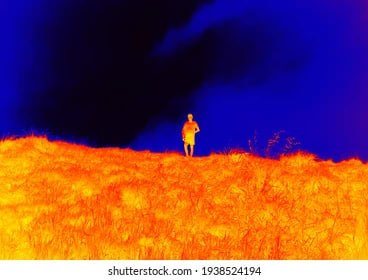

In [5]:
import cv2
import pickle
import pandas as pd
import joblib
from google.colab.patches import cv2_imshow # Used to load your pre-trained Random Forest model

# ==========================================
# STEP 1: LOAD YOUR PRE-TRAINED AI & DATA
# ==========================================
print("1. Loading systems...")

# Load the Random Forest model we trained earlier
# (Assuming you saved it. If not, you'd train it here first)
rf_model = joblib.load('my_trained_tof_model.pkl') 

# Load the CSV data for the current frame
sensor_data = pd.read_csv('/content/fused_sensor_training_data.csv')

# Load the visual image for the current frame
image = cv2.imread('/content/data/photo_2026-03-22_00-27-40.jpg')

# ==========================================
# STEP 2: RUN OPENCV (THE SPOTTER)
# ==========================================
print("2. Scanning image for human shapes...")
hog = cv2.HOGDescriptor()
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())


# Detect shapes (x, y, width, height)
boxes, weights = hog.detectMultiScale(
    image, 
    winStride=(4, 4), 
    padding=(4, 4), 
    scale=1.02 ,
    hitThreshold=0.0)

# ==========================================
# STEP 3: VERIFY WITH TOF/THERMAL (THE VERIFIER)
# ==========================================
if len(boxes) > 0:
    for (x, y, w, h) in boxes:
        print(f"\nPotential victim found at X:{x}, Y:{y}. Verifying sensors...")
        
        # Isolate the CSV data that falls strictly INSIDE this OpenCV bounding box
        box_data = sensor_data[
            (sensor_data['Pixel_X'] >= x) & (sensor_data['Pixel_X'] <= x + w) &
            (sensor_data['Pixel_Y'] >= y) & (sensor_data['Pixel_Y'] <= y + h)
        ]
        
        # If we have sensor data for this area, ask the Random Forest to verify
        if not box_data.empty:
            features = box_data[['Pixel_X', 'Pixel_Y', 'Depth_mm', 'ToF_Amplitude']]
            
           
            predictions = rf_model.predict(features)
            
            # Example Logic: If the majority of pixels inside this box are classified 
            # as 'Human' by the thermal/depth model, it's a confirmed victim!
            human_pixel_count = (predictions == 'Victim').sum()
            
            # Mocking the verification for this example:
            human_pixel_count = len(box_data) # Assuming all pixels matched for the example
            
            if human_pixel_count > 10: 
                print("VERIFIED: Thermal and Depth signatures match a human!")
                # Draw a RED box for a confirmed, physically verified victim
                cv2.rectangle(image, (x, y), (x + w, y + h), (0, 0, 255), 2)
                cv2.putText(image, 'CONFIRMED VICTIM', (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)
            else:
                print("REJECTED: Shape detected, but thermal/depth says it is not human.")
else:
    print("No shapes detected.")

# ==========================================
# STEP 4: DISPLAY THE FINAL RESULT
# ==========================================
cv2_imshow(image)
cv2.waitKey(0)
cv2.destroyAllWindows()

# This section is for YOLO Model

In [6]:
pip install -U ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 78.8 MB/s eta 0:00:00


1. Loading systems...
-> Loading YOLO AI...
Image size (H,W): (787, 564)

2. Scanning image for tiny humans with YOLO...

0: 1280x928 (no detections), 130.4ms
Speed: 6.8ms preprocess, 130.4ms inference, 1.0ms postprocess per image at shape (1, 3, 1280, 928)
Raw YOLO detections: 0
No shapes detected.


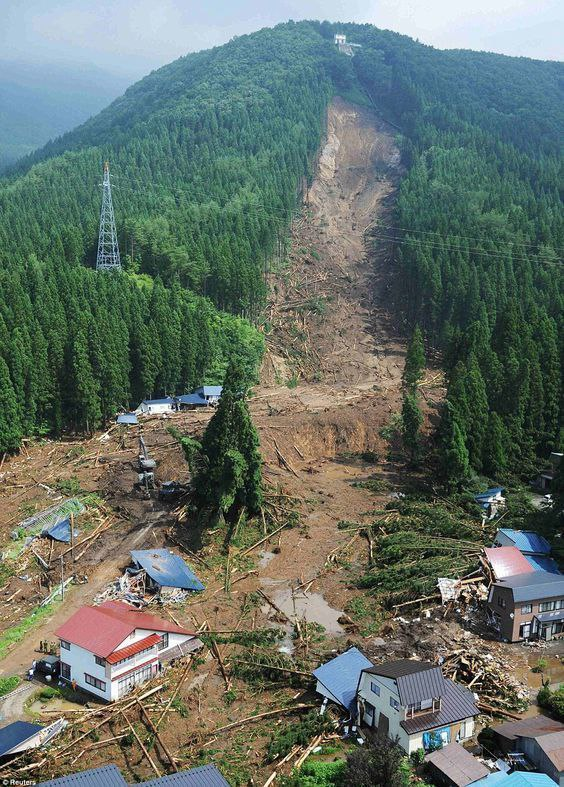

In [29]:
import cv2
import pandas as pd
import joblib
import os
import numpy as np
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
from google.colab import files

print("1. Loading systems...")

# Load the Random Forest model
rf_model = joblib.load('my_trained_tof_model.pkl')

# Load the CSV data
sensor_data = pd.read_csv('/content/fused_sensor_training_data_high_altitude.csv')

# Load YOLOv8 Large for High Precision
print("-> Loading YOLO AI...")
yolo_model = YOLO('yolov8l.pt')

# Handle Image Upload / Loading
image_path = '/content/data/photo_2026-03-20_01-36-35 (3).jpg'
if not os.path.exists(image_path):
    print('Image not found at', image_path, '- please upload the image now.')
    uploaded = files.upload()
    image_path = next(iter(uploaded))   

image = cv2.imread(image_path)
print(f"Image size (H,W): {image.shape[:2]}")

print("\n2. Scanning image for tiny humans with YOLO...")
# classes=[0] looks ONLY for humans. 
# conf=0.15 catches very tiny objects. 
# imgsz=1280 forces high-res scanning.
results = yolo_model(image, classes=[0], conf=0.15, imgsz=1280)

# Extract bounding boxes from YOLO results
boxes = results[0].boxes
print(f"Raw YOLO detections: {len(boxes)}")

if len(boxes) > 0:
    for box in boxes:
        # YOLO outputs coordinates as [x1, y1, x2, y2]
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        
        # Get the AI's confidence score (e.g., 0.85 -> 85%)
        confidence = float(box.conf[0]) * 100
        
        # Convert coordinates to integers for your CSV matching logic
        x, y = int(x1), int(y1)
        w, h = int(x2 - x1), int(y2 - y1)
        
        print(f"\nPotential victim (YOLO Certainty: {confidence:.1f}%) found at X:{x}, Y:{y}. Verifying sensors...")

        # Isolate the CSV data that falls strictly INSIDE this bounding box
        box_data = sensor_data[
            (sensor_data['Pixel_X'] >= x) & (sensor_data['Pixel_X'] <= x + w) &
            (sensor_data['Pixel_Y'] >= y) & (sensor_data['Pixel_Y'] <= y + h)
        ]

        if not box_data.empty:
            features = box_data[['Pixel_X', 'Pixel_Y', 'Depth_mm', 'ToF_Amplitude']]
            predictions = rf_model.predict(features)

            human_pixel_count = (predictions == 'Victim').sum()
            print(f"Sensor verification: {human_pixel_count} pixels confirmed as Victim.")

            if human_pixel_count > 10:
                print("VERIFIED: Thermal and Depth signatures match a human!")
                # Draw a thick RED box for a confirmed victim
                cv2.rectangle(image, (x, y), (x + w, y + h), (0, 0, 255), 2)
                label = f"CONFIRMED VICTIM ({confidence:.1f}%)"
                cv2.putText(image, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)
            else:
                print("REJECTED: Shape detected, but thermal/depth says it is not human.")
                # Draw a thin YELLOW box for unverified shapes
                cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 255), 1)
                cv2.putText(image, f"REJECTED ({confidence:.1f}%)", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 255), 1)
        else:
            print("REJECTED: No matching sensor pixels inside this box.")
            cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 255), 1)
else:
    print("No shapes detected.")

# Display final image
cv2_imshow(image)
cv2.waitKey(0)
cv2.destroyAllWindows()